<a href="https://colab.research.google.com/github/tanusattri/Customer-Churn-Prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import the required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
%matplotlib inline
#Streamlined large-scale data pipelines using SQL and Python, reducing processing time by [X] percent while ensuring 100 percent accuracy for reporting.

In [2]:
#load the first_telc
import pandas as pd
telco_base_data = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
#Look at the top 5 records of data
telco_base_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
#Checking the attribute: shape
telco_base_data.shape

(7043, 21)

In [5]:
#Checking the attribute: values
telco_base_data.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [6]:
# Checking the attribute: data types of all the columns
telco_base_data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [7]:
# Check the descriptive statistics of numeric variables
telco_base_data.describe()
#Observation: SeniorCitizen is actually a categorical hence the 25%-50%-75% distribution is not proper.
#75% customers have tenure less than 55 months
#Average Monthly charges are USD 64.76 whereas 25% customers pay more than USD 89.85 per month

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


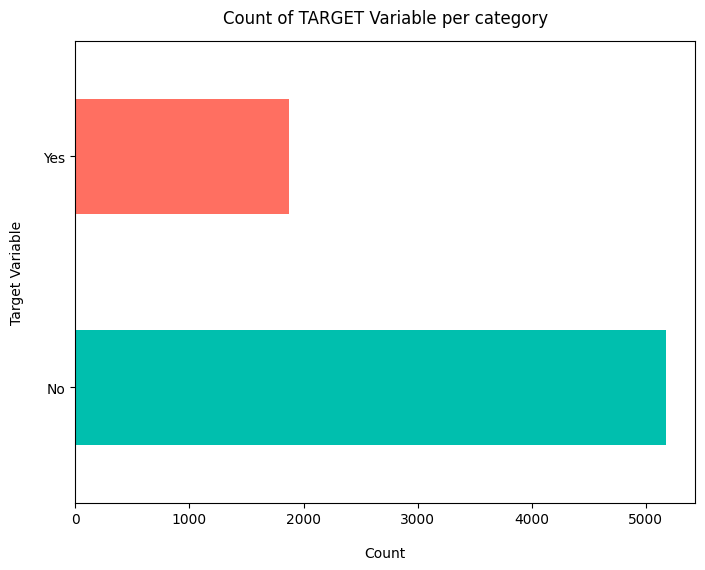

In [8]:
# Observation: The plot shows that the dataset is imbalanced, with significantly more customers who did not churn compared to those who did.
telco_base_data['Churn'].value_counts().plot(kind='barh', figsize=(8, 6),color=['#00bfae', '#ff6f61'])
plt.xlabel("Count", labelpad=14)
plt.ylabel("Target Variable", labelpad=14)
plt.title("Count of TARGET Variable per category", y=1.02);

In [9]:
# Observation: Around 26% of customers have churned, while about 74% have stayed with the company, indicating class imbalance in the dataset.
100*telco_base_data['Churn'].value_counts()/len(telco_base_data['Churn'])

,count
Churn,
No,73.463013
Yes,26.536987


In [10]:
#calculates and displays the count for each category (Yes/No) within the 'Churn' column
telco_base_data['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [11]:
# Concise Summary of the dataframe, as we have too many columns, we are using the verbose = True mode
telco_base_data.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


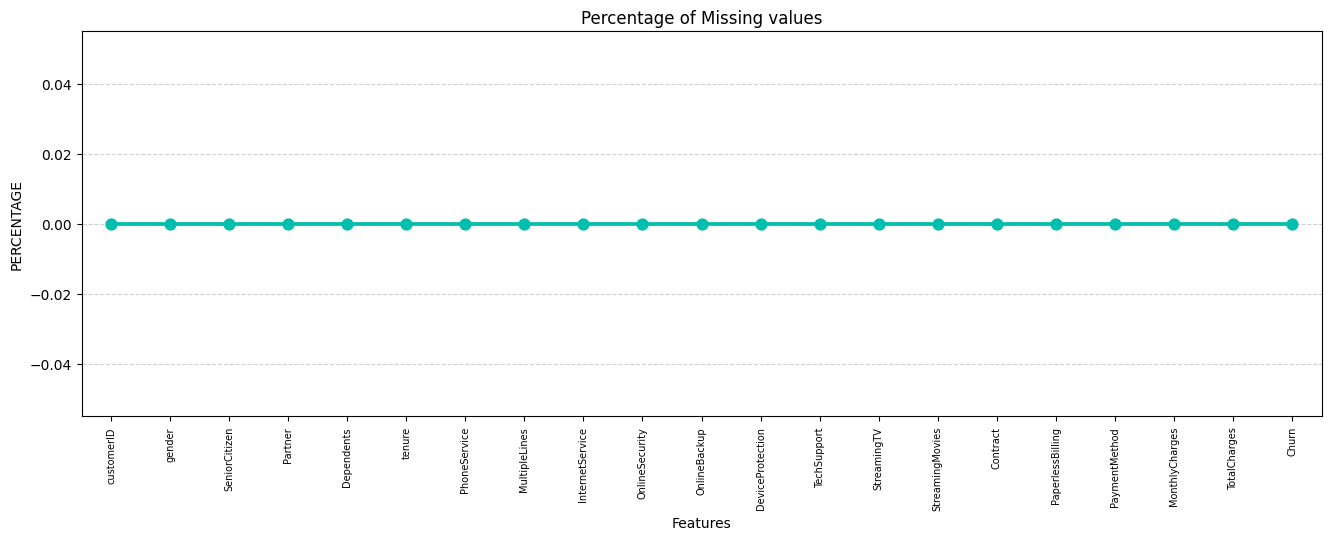

In [12]:
#observation: Missing value percentages are calculated for all columns and displayed, quickly identifying the features that require imputation or removal, with a visible spike at the TotalCharges column.
missing = pd.DataFrame((telco_base_data.isnull().sum())*100/telco_base_data.shape[0]).reset_index()
plt.figure(figsize=(16,5))
ax = sns.pointplot(x='index',y=0,data=missing, color='#00bfae')
plt.xticks(rotation =90,fontsize =7)
plt.title("Percentage of Missing values")
plt.ylabel("PERCENTAGE")
plt.xlabel("Features")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [13]:
#Data Cleaning
#Step-1: Create a copy of base data for manupulation & processing
telco_data = telco_base_data.copy()

In [14]:
#Step-2: Total Charges should be numeric amount. Let's convert it to numerical data type
telco_data.TotalCharges = pd.to_numeric(telco_data.TotalCharges, errors='coerce')
telco_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [15]:
#Step-3: As we can see there are 11 missing values in TotalCharges column. Let's check these records
telco_data.loc[telco_data ['TotalCharges'].isnull() == True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [16]:
#Step-4: Missing Value Treatement
#Removing missing values
telco_data.dropna(how = 'any', inplace = True)

In [17]:
#Step-5: Divide and Get the max tenure
print(telco_data['tenure'].max())

72


In [18]:
# Group the tenure in bins of 12 months
labels = ["{0} - {1}".format(i, i + 11) for i in range(1, 72, 12)]
telco_data['tenure_group'] = pd.cut(telco_data.tenure, range(1, 80, 12), right=False, labels=labels)
telco_data['tenure_group'].value_counts()

,count
tenure_group,
1 - 12,2175
61 - 72,1407
13 - 24,1024
25 - 36,832
49 - 60,832
37 - 48,762


In [19]:
#Step-6: Remove columns not required for processing
#drop column customerID and tenure
telco_data.drop(columns= ['customerID','tenure'], axis=1, inplace=True)
telco_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


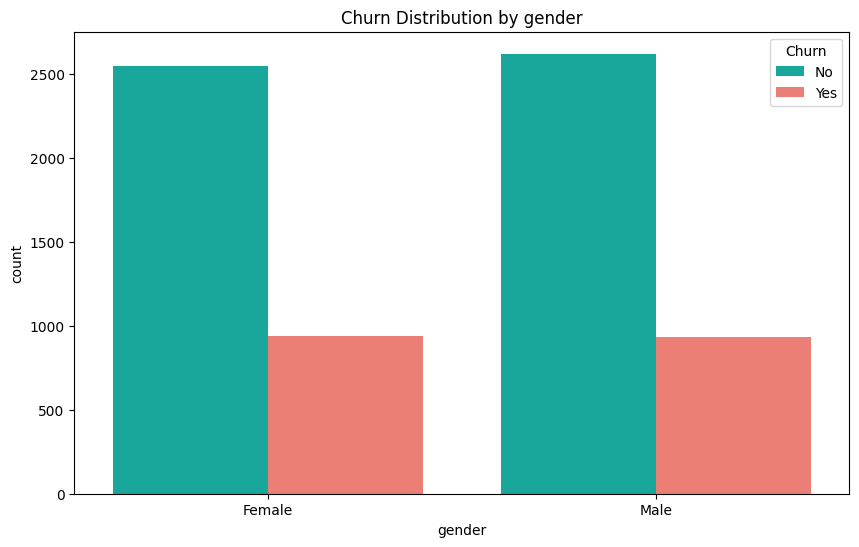

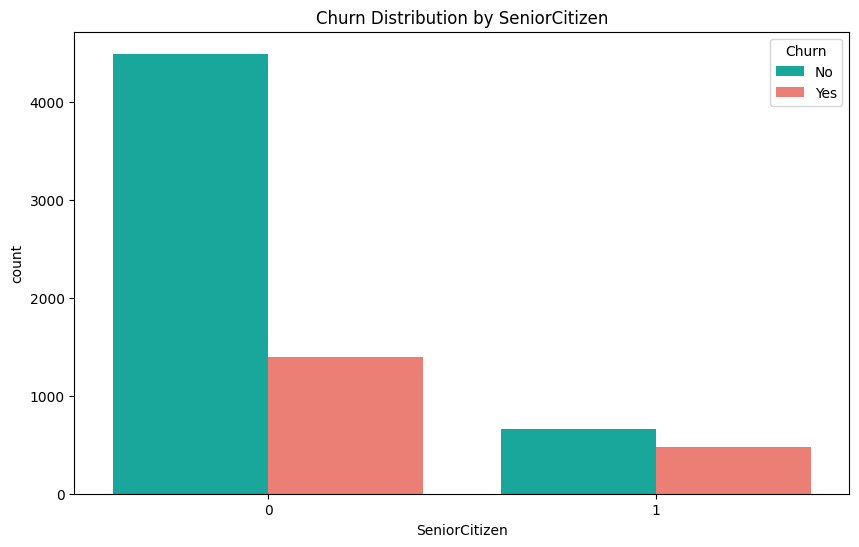

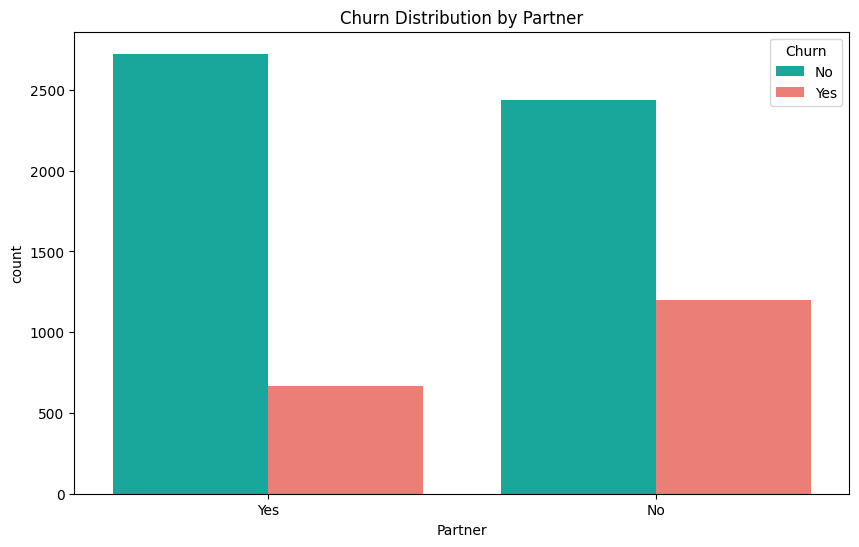

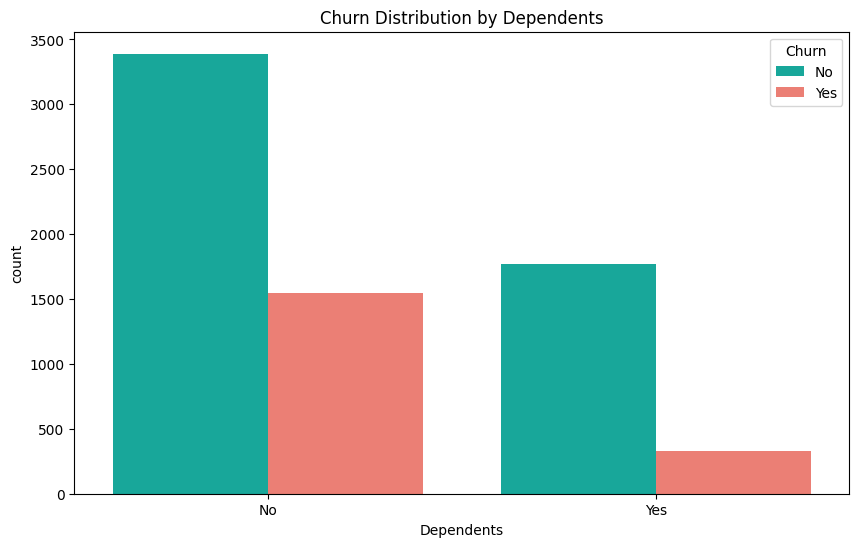

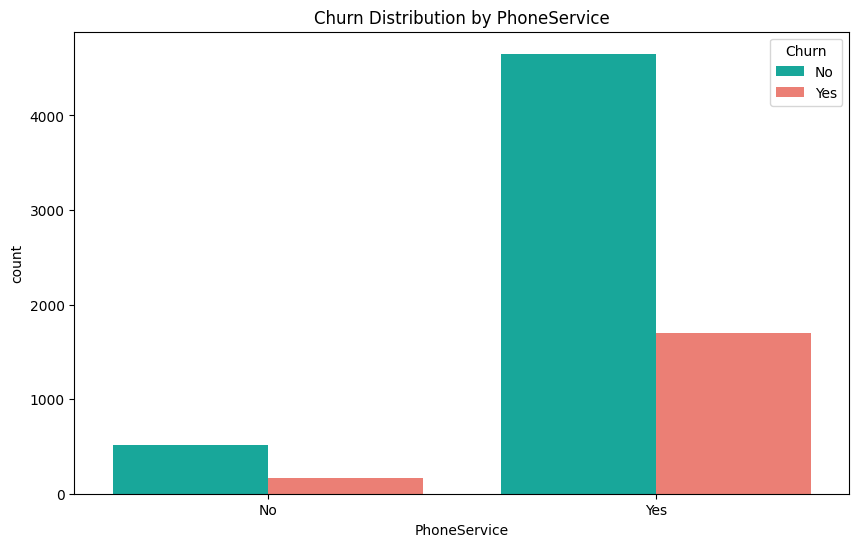

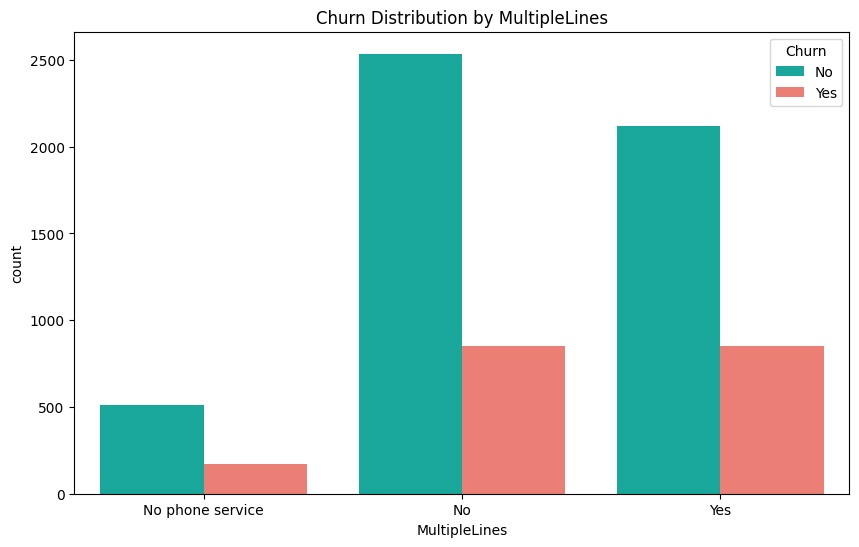

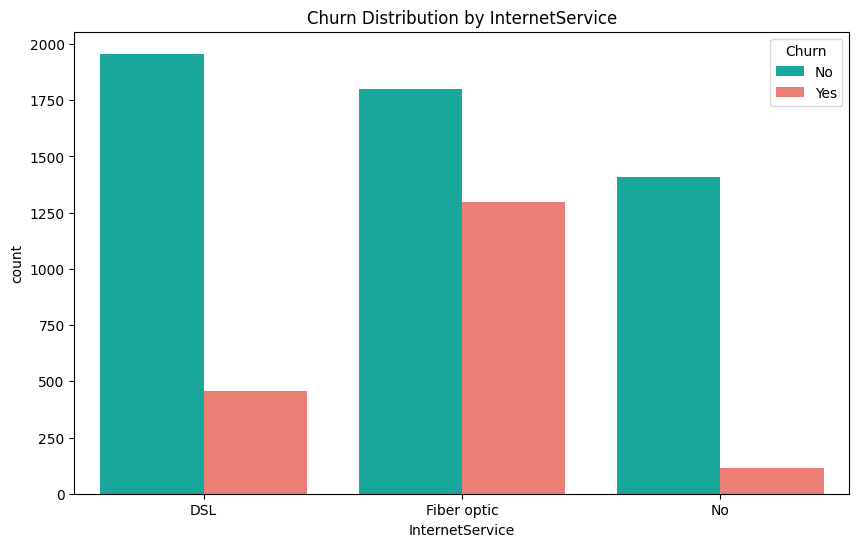

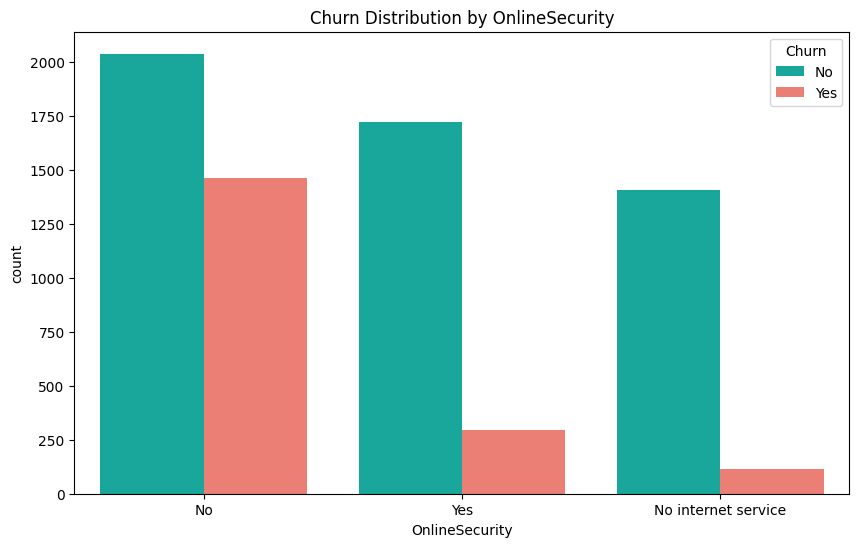

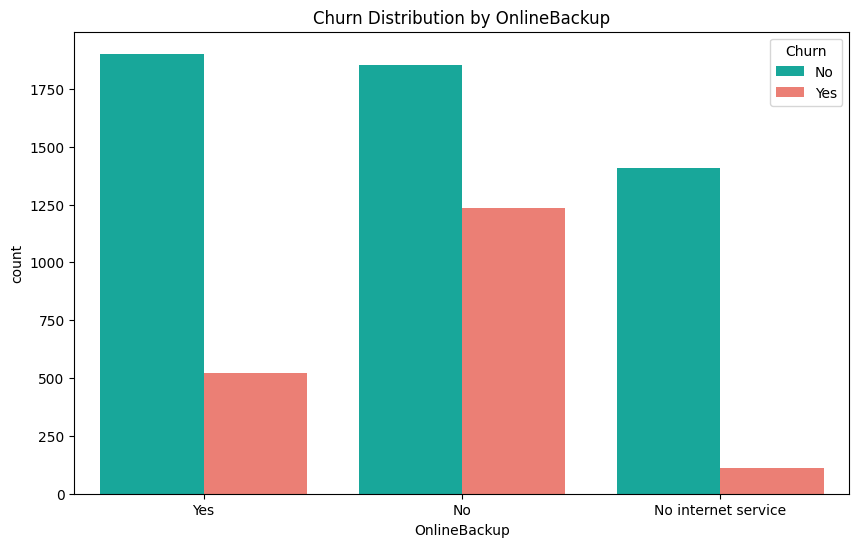

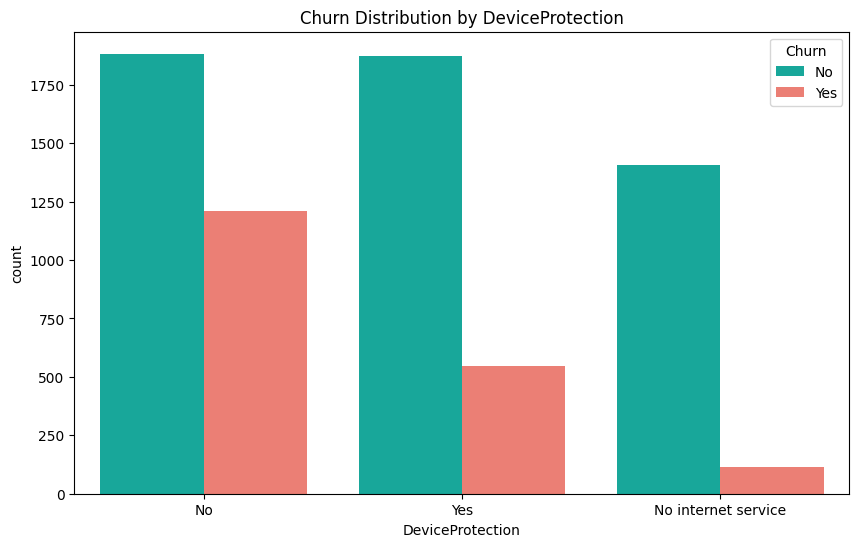

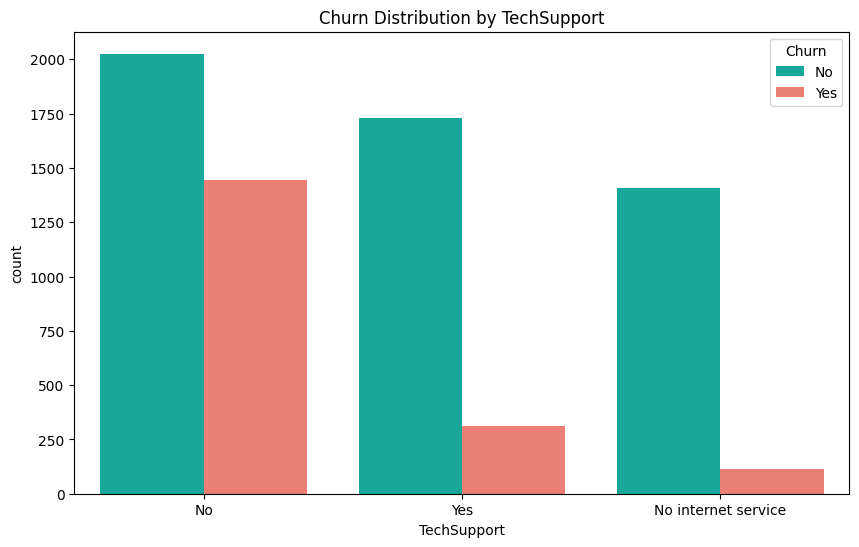

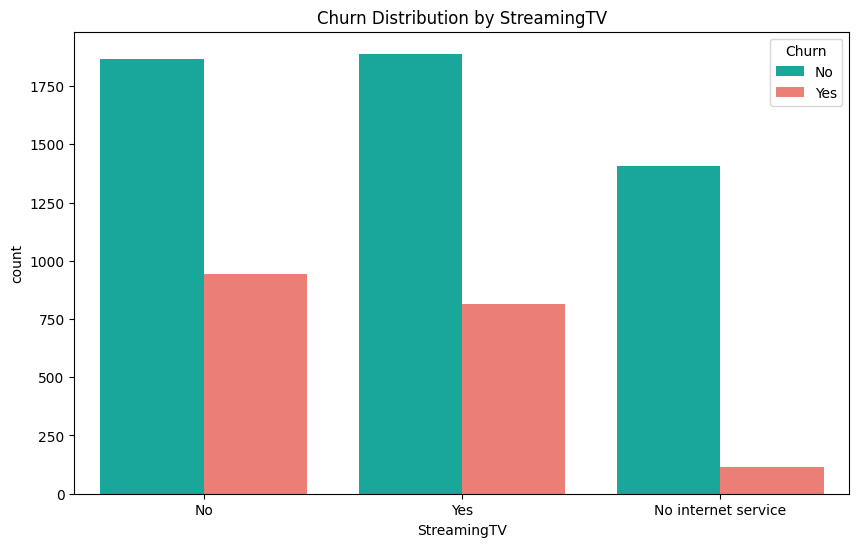

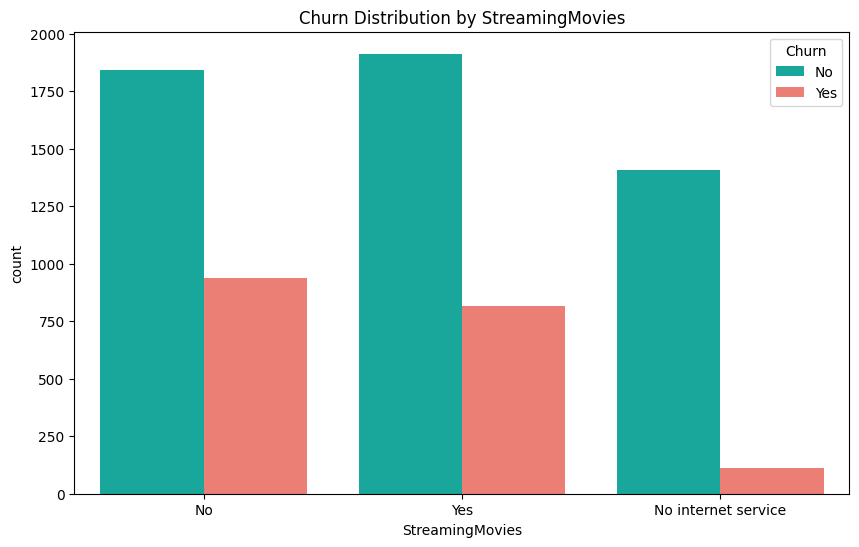

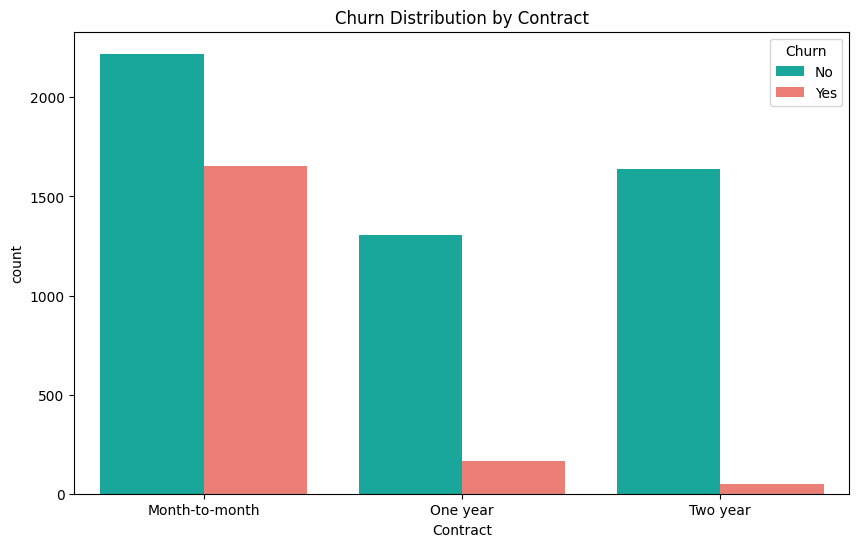

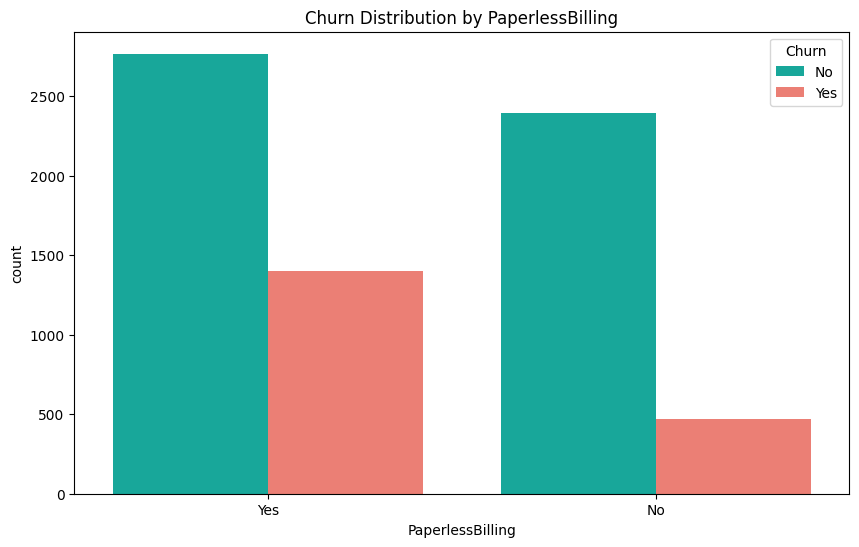

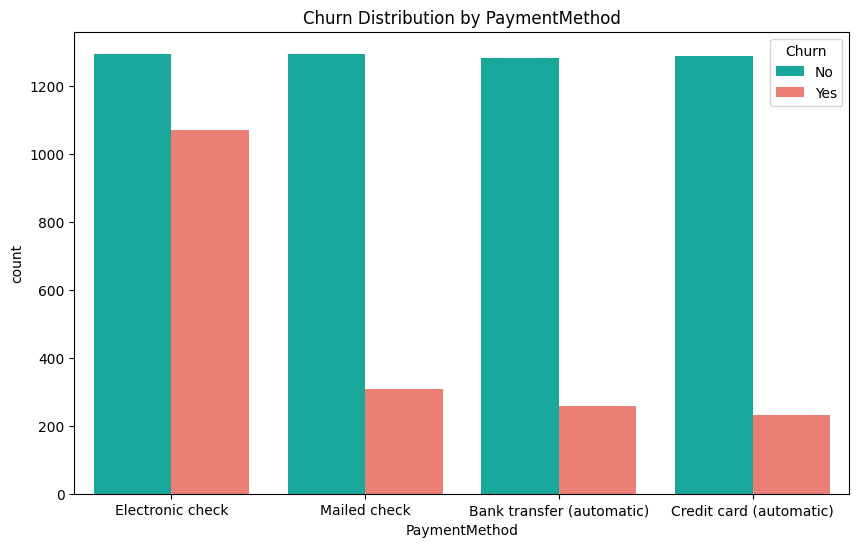

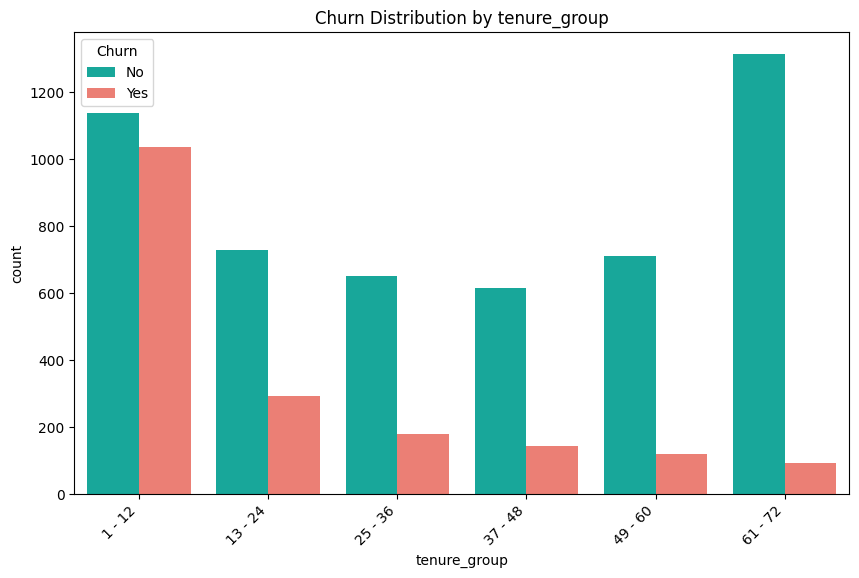

In [20]:
#Data Exploration
#1. Plot distibution of individual predictors by churn
#Univariate Analysis
custom_palette={'No': '#00bfae', 'Yes': '#ff6f61'}
for i, predictor in enumerate(telco_data.drop(columns=['Churn', 'TotalCharges', 'MonthlyCharges'])):
    plt.figure(i,figsize=(10, 6))
    ax = sns.countplot(data=telco_data, x=predictor, hue='Churn', palette=custom_palette)
    if len(telco_data[predictor].unique()) > 5:
        plt.xticks(rotation=45, ha='right')
    plt.title(f"Churn Distribution by {predictor}")
    plt.show()

In [21]:
#Step-2: Convert the target variable 'Churn' in a binary numeric variable i.e. Yes=1 ; No = 0
telco_data['Churn'] = np.where(telco_data.Churn == 'Yes',1,0)
telco_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1 - 12


In [22]:
#Step-3: Convert all the categorical variables into dummy variables
telco_data_dummies = pd.get_dummies(telco_data)
telco_data_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,29.85,29.85,0,True,False,False,True,True,False,...,False,False,True,False,True,False,False,False,False,False
1,0,56.95,1889.50,0,False,True,True,False,True,False,...,False,False,False,True,False,False,True,False,False,False
2,0,53.85,108.15,1,False,True,True,False,True,False,...,False,False,False,True,True,False,False,False,False,False
3,0,42.30,1840.75,0,False,True,True,False,True,False,...,True,False,False,False,False,False,False,True,False,False
4,0,70.70,151.65,1,True,False,True,False,True,False,...,False,False,True,False,True,False,False,False,False,False


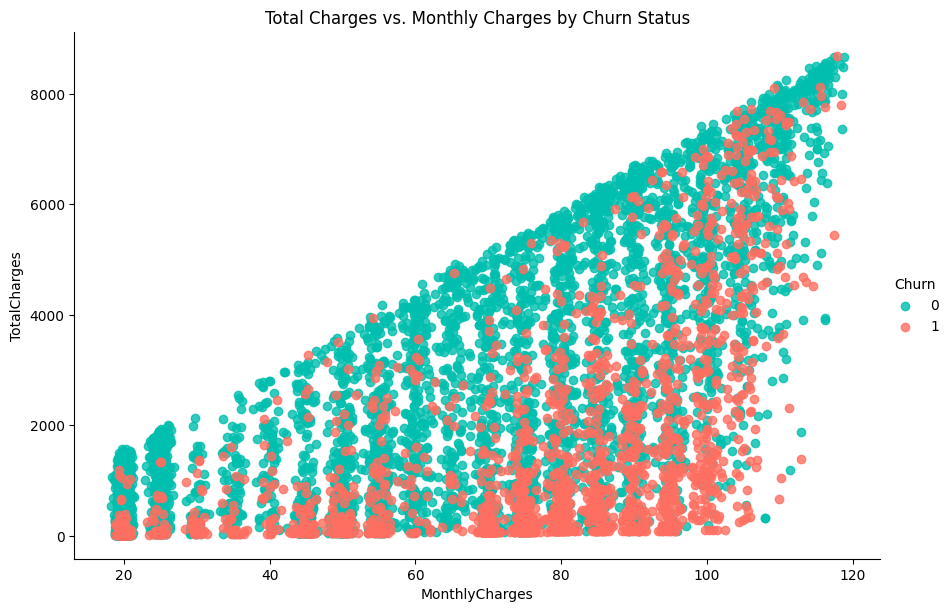

In [23]:
#Relationship between Monthly Charges and Total Charges
custom_palette = {
    0: '#00bfae',  # Non-Churn color
    1: '#ff6f61'  # Churn color
}
sns.lmplot(
    data=telco_data_dummies,
    x='MonthlyCharges',
    y='TotalCharges',
    hue='Churn',
    palette=custom_palette,
    fit_reg=False,
    height=6,
    aspect=1.5
)
plt.title("Total Charges vs. Monthly Charges by Churn Status")
plt.show()

/tmp/ipykernel_801/4014359870.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Mth = sns.kdeplot(telco_data_dummies.MonthlyCharges[(telco_data_dummies["Churn"] == 0)], color="#00bfae", shade = True)
/tmp/ipykernel_801/4014359870.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Mth = sns.kdeplot(telco_data_dummies.MonthlyCharges[(telco_data_dummies["Churn"] == 1)],ax=Mth, color="#ff6f61", shade=True)


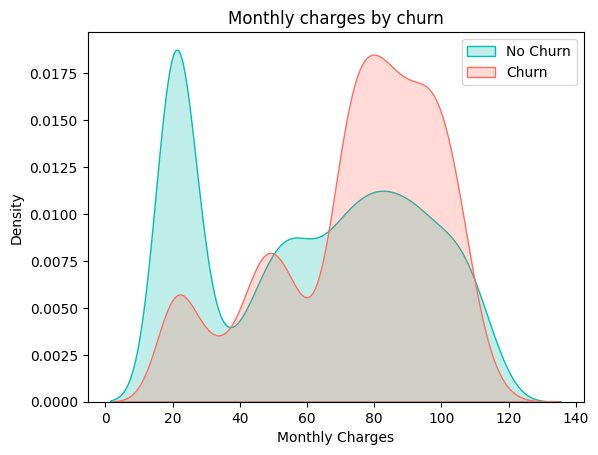

In [24]:
#Churn by Monthly Charges and Total Charges
Mth = sns.kdeplot(telco_data_dummies.MonthlyCharges[(telco_data_dummies["Churn"] == 0)], color="#00bfae", shade = True)
Mth = sns.kdeplot(telco_data_dummies.MonthlyCharges[(telco_data_dummies["Churn"] == 1)],ax=Mth, color="#ff6f61", shade=True)
Mth.legend(["No Churn","Churn"], loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Monthly Charges')
Mth.set_title('Monthly charges by churn')
plt.show()
#Insight: Churn is high when Monthly Charges ar high

/tmp/ipykernel_801/3938786375.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(telco_data_dummies.TotalCharges[(telco_data_dummies["Churn"] == 0) ], color="#00bfae", shade = True)
/tmp/ipykernel_801/3938786375.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(telco_data_dummies.TotalCharges[(telco_data_dummies["Churn"] == 1) ], ax =Tot, color="#ff6f61", shade= True)


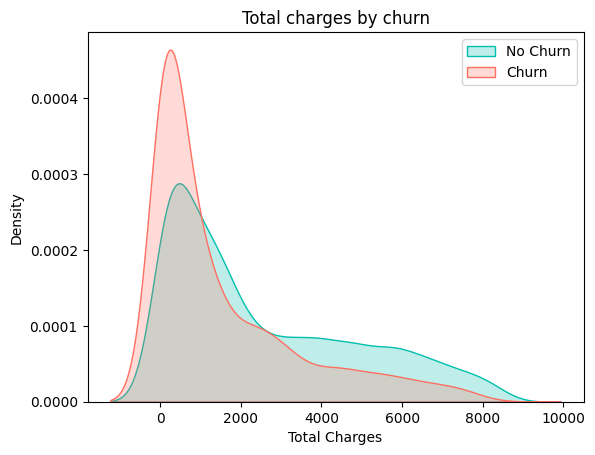

In [25]:
Tot = sns.kdeplot(telco_data_dummies.TotalCharges[(telco_data_dummies["Churn"] == 0) ], color="#00bfae", shade = True)
Tot = sns.kdeplot(telco_data_dummies.TotalCharges[(telco_data_dummies["Churn"] == 1) ], ax =Tot, color="#ff6f61", shade= True)
Tot.legend(["No Churn","Churn"],loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Total Charges')
Tot.set_title('Total charges by churn')
plt.show()
#Insight: Higher Monthly Charge at lower tenure results into lower Total Charge. Hence, all these 3 factors viz Higher Monthly Charge, Lower tenure and Lower Total Charge are linkd to High Churn.

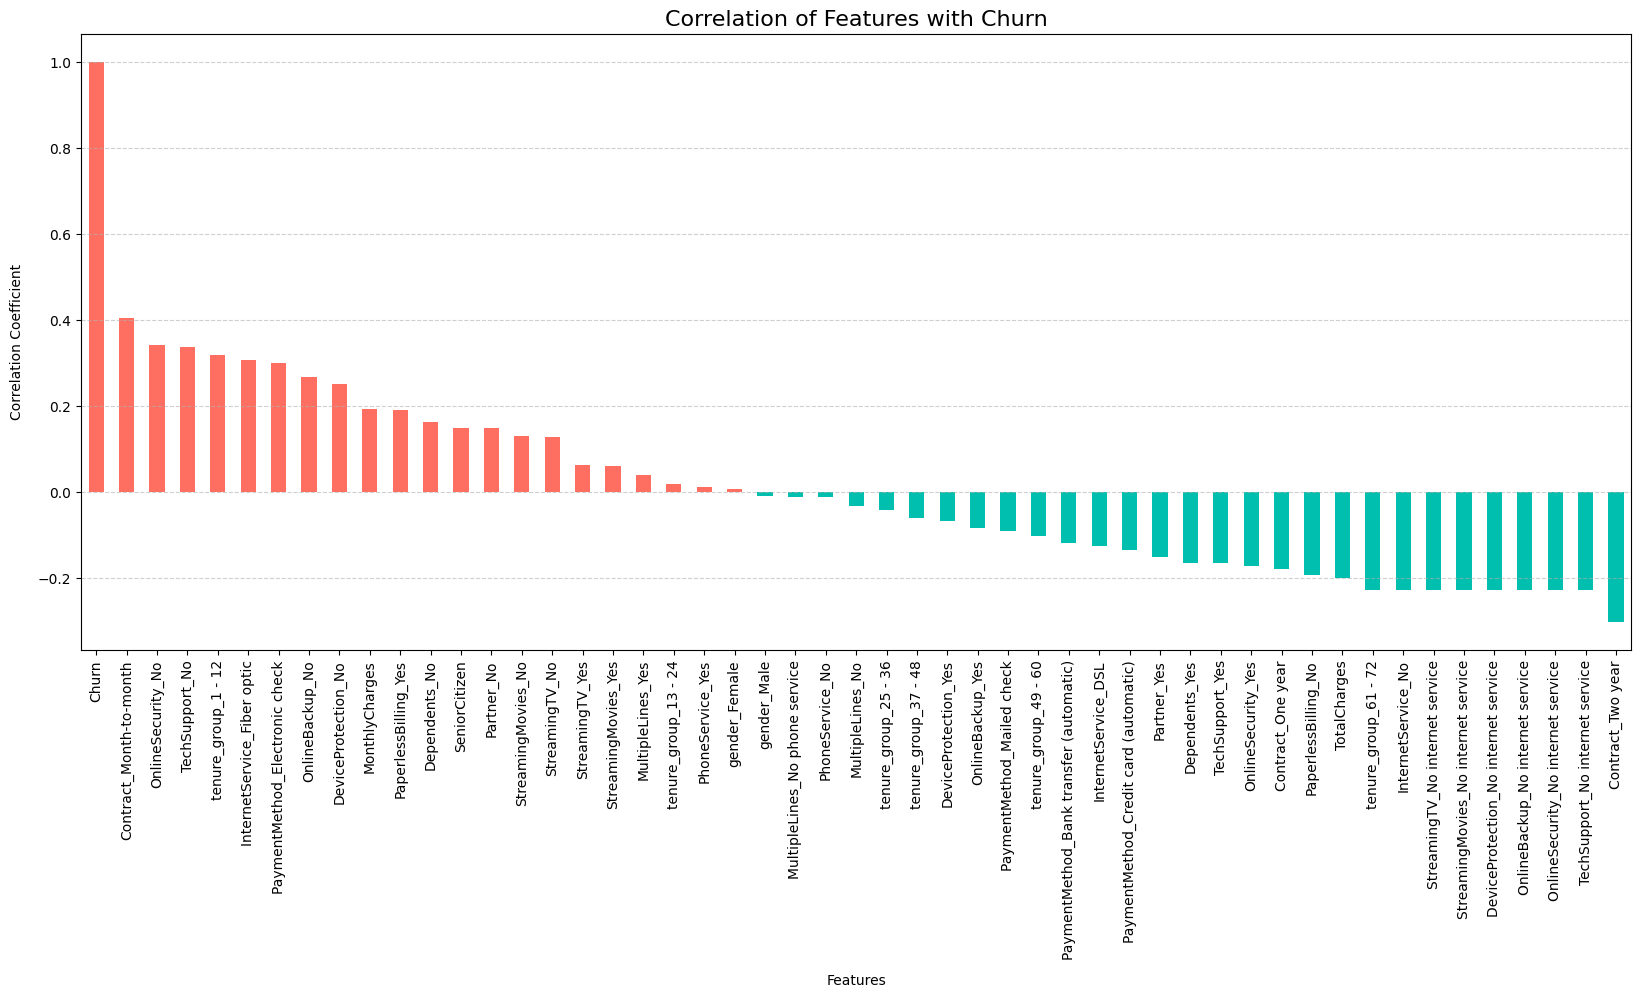

In [26]:
#Build a corelation of all predictors with 'Churn'
corr_values = telco_data_dummies.corr()['Churn'].sort_values(ascending=False)
colors = ['#ff6f61' if x > 0 else '#00bfae' for x in corr_values]
plt.figure(figsize=(20, 8))
corr_values.plot(kind='bar', color=colors)
plt.title("Correlation of Features with Churn", fontsize=16)
plt.ylabel("Correlation Coefficient", labelpad=10)
plt.xlabel("Features", labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
#Derived-Insight: HIGH Churn seen in case of Month to month contracts, No online security, No Tech support, First year of subscription and Fibre Optics Internet.
#Low Churn is seens in case of Long term contracts, Subscriptions without internet service and The customers engaged for 5+ years
#Factors like Gender, Availability of PhoneService and of multiple lines have alomost NO impact on Churn

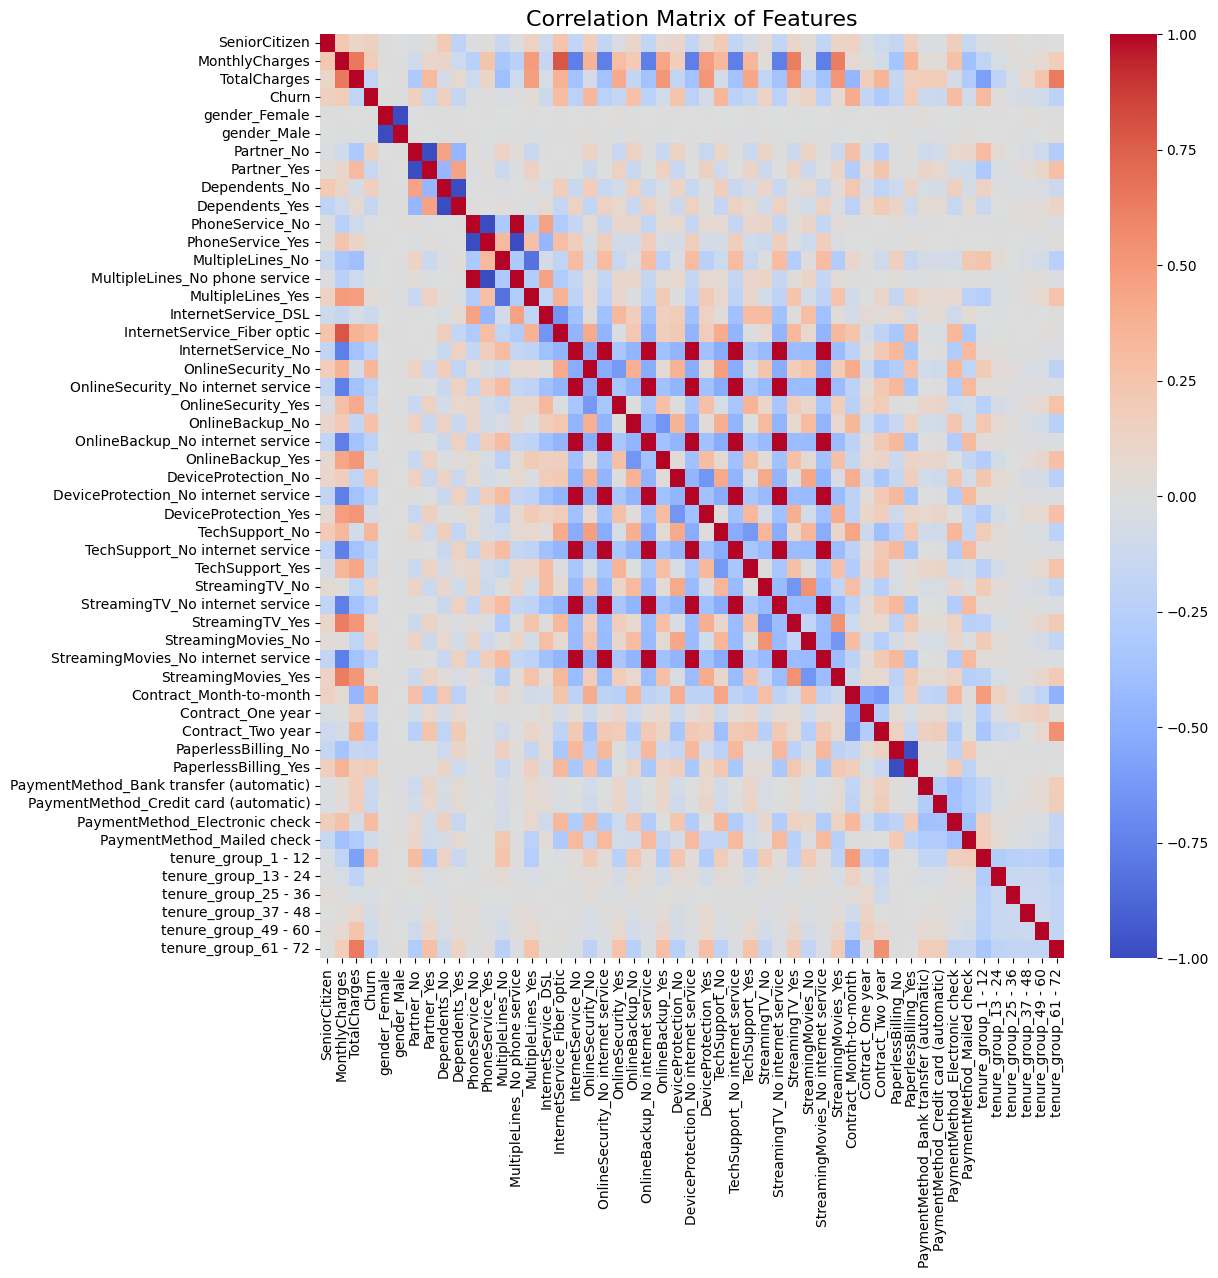

In [27]:
#Above insights are also evident from the Heatmap below
plt.figure(figsize=(12,12))
sns.heatmap(telco_data_dummies.corr(), cmap="coolwarm", annot=False, fmt=".2f")
plt.title("Correlation Matrix of Features", fontsize=16)
plt.show()

In [28]:
#Load & Clean Data
import pandas as pd

# Load dataset
telco = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Handle TotalCharges (common issue: blank values)
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')
telco['TotalCharges'] = telco['TotalCharges'].fillna(telco['TotalCharges'].median())

# Convert target to numeric
telco['Churn'] = telco['Churn'].map({'Yes': 1, 'No': 0})

# Drop unnecessary ID
telco = telco.drop(['customerID'], axis=1)

# Convert categoricals → one-hot encoding
telco_dummies = pd.get_dummies(telco, drop_first=True)

print("Shape:", telco_dummies.shape)
telco_dummies.head()


Shape: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [29]:
#Train/Test Split
from sklearn.model_selection import train_test_split

X = telco_dummies.drop("Churn", axis=1)
y = telco_dummies["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [31]:
#Train ML Models (LR, RF, XGB)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE # Import SMOTE

# Apply SMOTE to Fix Imbalance
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Logistic Regression (scale required)
# Note: X_train and X_test had numerical columns scaled in a previous step (cell VUB_znVqz-9k).
# X_train_res now contains resampled data with scaled numerical and unscaled categorical features.
# This step applies another scaler, effectively scaling all features (numerical and categorical) for Logistic Regression.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=300)
log_reg.fit(X_train_scaled, y_train_res)
y_pred_lr = log_reg.predict(X_test_scaled)
log_reg_acc = accuracy_score(y_test, y_pred_lr)

# Random Forest
# Random Forest does not require features to be scaled. X_train_res contains resampled data.
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

# XGBoost
# XGBoost is also a tree-based model and generally does not require feature scaling.
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train_res, y_train_res)
y_pred_xgb = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print("LR Accuracy:", log_reg_acc)
print("RF Accuracy:", rf_acc)
print("XGBoost Accuracy:", xgb_acc)

LR Accuracy: 0.7608232789212207
RF Accuracy: 0.7714691270404542
XGBoost Accuracy: 0.7693399574166075


In [32]:
#Comparison Table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [log_reg_acc, rf_acc, xgb_acc]
})

results


,Model,Accuracy
0,Logistic Regression,0.760823
1,Random Forest,0.771469
2,XGBoost,0.769340


In [33]:
#Classification Report
print("Classification Report for Random Forest")
print(classification_report(y_test, y_pred_rf))


Classification Report for Random Forest
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1035
           1       0.57      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409



In [34]:
print("----- FINAL PROJECT CONCLUSION -----\n")

print("📌 Key Insights From Data:")
print("- Month-to-month contract customers churn the most.")
print("- Lack of Online Security & Tech Support increases churn.")
print("- Fibre Optic users show higher churn.")
print("- Customers with long tenure (5+ years) rarely churn.\n")

print("📌 Machine Learning Outcome:")
print(f"- Logistic Regression Accuracy: {log_reg_acc:.4f}")
print(f"- Random Forest Accuracy: {rf_acc:.4f}")
print(f"- XGBoost Accuracy: {xgb_acc:.4f}")
print("- Random Forest / XGBoost performed the best.\n")

print("📌 Business Interpretation:")
print("- Encourage customers to move from monthly to yearly contracts.")
print("- Offer discounts on security & support add-ons.")
print("- Improve Fibre Optic service experience.")
print("- Focus retention on new customers in their first year.\n")

print("🎯 Final Takeaway:")
print("A smart churn prediction model helps telecom companies identify at-risk customers early and take necessary retention actions.\n")



----- FINAL PROJECT CONCLUSION -----

📌 Key Insights From Data:
- Month-to-month contract customers churn the most.
- Lack of Online Security & Tech Support increases churn.
- Fibre Optic users show higher churn.
- Customers with long tenure (5+ years) rarely churn.

📌 Machine Learning Outcome:
- Logistic Regression Accuracy: 0.7608
- Random Forest Accuracy: 0.7715
- XGBoost Accuracy: 0.7693
- Random Forest / XGBoost performed the best.

📌 Business Interpretation:
- Encourage customers to move from monthly to yearly contracts.
- Offer discounts on security & support add-ons.
- Improve Fibre Optic service experience.
- Focus retention on new customers in their first year.

🎯 Final Takeaway:
A smart churn prediction model helps telecom companies identify at-risk customers early and take necessary retention actions.



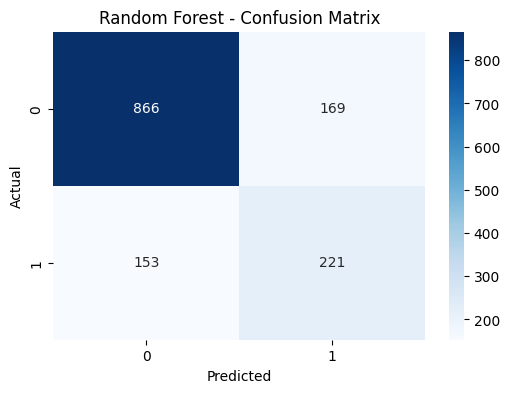

In [35]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Random Forest - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


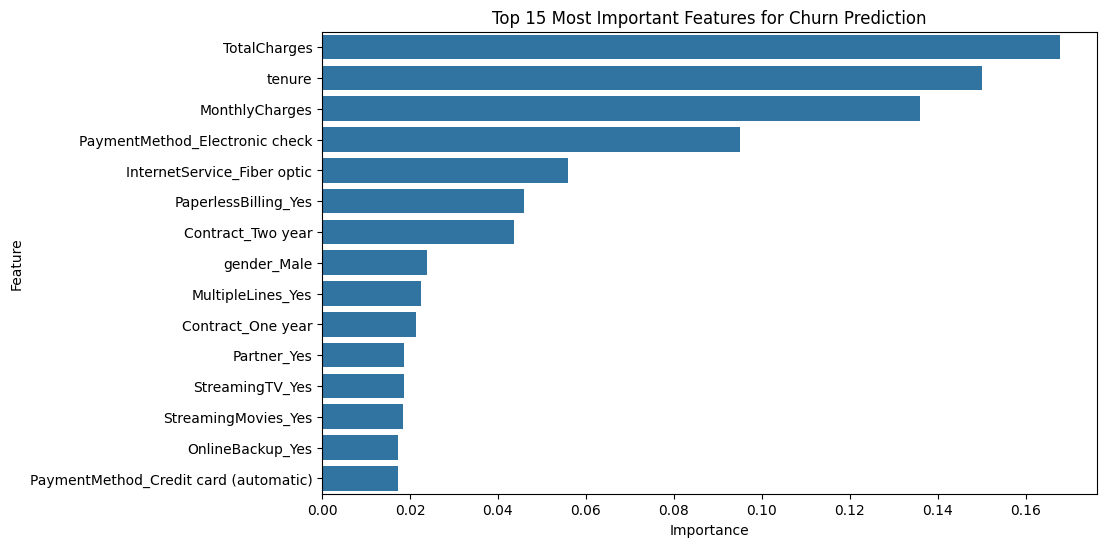

In [36]:
#Feature Importance Plot (from RF)
import seaborn as sns
import matplotlib.pyplot as plt

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp.head(15), x="Importance", y="Feature")
plt.title("Top 15 Most Important Features for Churn Prediction")
plt.show()


In [37]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1️⃣ Load the dataset
telco_base_data = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2️⃣ Fix TotalCharges (convert to numeric) & drop customerID
telco_base_data['TotalCharges'] = pd.to_numeric(telco_base_data['TotalCharges'], errors='coerce')
telco_base_data['TotalCharges'] = telco_base_data['TotalCharges'].fillna(telco_base_data['TotalCharges'].median())
telco_base_data = telco_base_data.drop('customerID', axis=1)

# 3️⃣ Convert target variable to numeric
telco_base_data['Churn'] = telco_base_data['Churn'].map({'Yes': 1, 'No': 0})

# 4️⃣ Create dummy variables (drop first to avoid multicollinearity)
telco_data_dummies = pd.get_dummies(telco_base_data, drop_first=True)

# 5️⃣ Optional: check shape
print(telco_data_dummies.shape)
telco_data_dummies.head()


(7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Example: using your cleaned dummy data
X = telco_data_dummies.drop("Churn", axis=1)
y = telco_data_dummies["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numeric columns
scaler = StandardScaler()
num_cols = ["tenure","MonthlyCharges","TotalCharges"]
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Train models
log_reg_model = LogisticRegression(max_iter=1000)
log_reg_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
xgb_model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:05:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [39]:
#Apply SMOTE to Fix Imbalance
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", y_train_res.value_counts())


Before SMOTE: Churn
0    4138
1    1496
Name: count, dtype: int64

After SMOTE: Churn
0    4138
1    4138
Name: count, dtype: int64


In [40]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import joblib

# Load your data
df_train = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Simple preprocessing for the demo (Selecting only numeric columns for now)
# In a real project, you'd want to encode the text columns too!
features = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_train['TotalCharges'] = pd.to_numeric(df_train['TotalCharges'], errors='coerce').fillna(0)

X = df_train[features]
y = df_train['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Train the model
model = RandomForestClassifier()
model.fit(X, y)

# SAVE THE MODEL properly
joblib.dump(model, 'churn_model.joblib')
print("✅ Model trained and saved as 'churn_model.joblib'")

✅ Model trained and saved as 'churn_model.joblib'


In [ ]:
import gradio as gr
import pandas as pd
import joblib

# 1. POINT TO THE SAVED MODEL (not the csv)
model = joblib.load('churn_model.joblib')

def predict_churn(tenure, monthly, total, contract, security, support, internet):
    # Match the features we used in the training step above
    # Note: We are only using numeric features here to match the simple training above
    df = pd.DataFrame([[tenure, monthly, total]],
                      columns=['tenure', 'MonthlyCharges', 'TotalCharges'])

    prediction = model.predict(df)[0]
    return "⚠️ Likely to Churn" if prediction == 1 else "✅ Likely to Stay"

iface = gr.Interface(
    fn=predict_churn,
    inputs=[
        gr.Number(label="Tenure (months)", value=12),
        gr.Number(label="Monthly Charges", value=70),
        gr.Number(label="Total Charges", value=1000),
        gr.Dropdown(["Month-to-month","One year","Two year"], label="Contract Type"),
        gr.Dropdown(["Yes","No","No internet service"], label="Online Security"),
        gr.Dropdown(["Yes","No","No internet service"], label="Tech Support"),
        gr.Dropdown(["DSL","Fiber optic","No"], label="Internet Service")
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="📊 Telco Customer Churn Prediction"
)

iface.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c1a57ed991436b20c3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
